# Stage A — Merged-file inventory & QA

Scan `/home/slow_data/Air_Quality/Stage_A/merged/YYYY/MM/DD/merged_YYYYMMDD_HHMM.nc` and check:

1. **Date / slot coverage** — which days are present, how many 30-min slots each day (max 48).
2. **Per-variable validity** — non-NaN pixel counts for every data variable.
3. **Sensor contribution** — distribution of `n_sensors`, `confidence_flag`, `dominant_sensor`.
4. **AOD value sanity** — min / max / mean / quantiles of `AOD_merged` and `AOD_phys_corrected`.
5. **Sample plot** — quick map of one slot.

Adjust `START` / `END` below to restrict the scan range.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from config import MERGED_DIR, LATS, LONS, NLAT, NLON, SLOT_MINUTES

print('MERGED_DIR :', MERGED_DIR)
print('grid       :', NLAT, '×', NLON)
print('slot every :', SLOT_MINUTES, 'min  →', 24 * 60 // SLOT_MINUTES, 'slots/day')

MERGED_DIR : /home/slow_data/Air_Quality/Stage_A/merged
grid       : 310 × 160
slot every : 30 min  → 48 slots/day


## 1. Walk the directory tree

In [2]:
# Restrict to a date range — set to None to scan everything.
START = None     # e.g. datetime(2024, 1, 1)
END   = None     # e.g. datetime(2024, 12, 31)

FNAME_RE = re.compile(r'^merged_(\d{8})_(\d{4})\.nc$')

rows = []
for p in Path(MERGED_DIR).rglob('merged_*.nc'):
    m = FNAME_RE.match(p.name)
    if not m:
        continue
    date_s, time_s = m.groups()
    ts = datetime.strptime(date_s + time_s, '%Y%m%d%H%M')
    if START and ts < START:
        continue
    if END and ts > END:
        continue
    rows.append({
        'path': p,
        'timestamp': ts,
        'date': ts.date(),
        'slot': ts.strftime('%H%M'),
        'size_kb': p.stat().st_size / 1024,
    })

inv = pd.DataFrame(rows).sort_values('timestamp').reset_index(drop=True)
print(f'Found {len(inv):,} merged NetCDF files.')
if len(inv):
    print(f'Range : {inv.timestamp.min()}  →  {inv.timestamp.max()}')
inv.head()

Found 26,795 merged NetCDF files.
Range : 2022-09-01 00:00:00  →  2026-04-30 10:00:00


,path,timestamp,date,slot,size_kb
0,/home/slow_data/Air_Quality/Stage_A/merged/202...,2022-09-01 00:00:00,2022-09-01,0000,264.697266
1,/home/slow_data/Air_Quality/Stage_A/merged/202...,2022-09-01 00:30:00,2022-09-01,0030,264.697266
2,/home/slow_data/Air_Quality/Stage_A/merged/202...,2022-09-01 01:00:00,2022-09-01,0100,261.889648
3,/home/slow_data/Air_Quality/Stage_A/merged/202...,2022-09-01 01:30:00,2022-09-01,0130,261.889648
4,/home/slow_data/Air_Quality/Stage_A/merged/202...,2022-09-01 02:00:00,2022-09-01,0200,261.087891


## 2. Daily slot coverage

Each calendar day should have 48 thirty-minute slots (00:00 → 23:30 UTC). Find days that fall short.

In [3]:
SLOTS_PER_DAY = 24 * 60 // SLOT_MINUTES

daily = (
    inv.groupby('date')
       .agg(slots=('slot', 'nunique'), total_kb=('size_kb', 'sum'))
       .reset_index()
)
daily['missing'] = SLOTS_PER_DAY - daily['slots']

if len(daily):
    full_idx = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D').date
    daily = daily.set_index('date').reindex(full_idx).reset_index()
    daily.rename(columns={'index': 'date'}, inplace=True)
    daily['slots'] = daily['slots'].fillna(0).astype(int)
    daily['missing'] = (SLOTS_PER_DAY - daily['slots']).astype(int)

print('Days with files          :', (daily['slots'] > 0).sum())
print('Days with 0 slots        :', (daily['slots'] == 0).sum())
print('Days fully covered (48)  :', (daily['slots'] == SLOTS_PER_DAY).sum())
print('Days partial (1..47)     :', ((daily['slots'] > 0) & (daily['slots'] < SLOTS_PER_DAY)).sum())

daily.head(10)

Days with files          : 1338
Days with 0 slots        : 0
Days fully covered (48)  : 0
Days partial (1..47)     : 1338


,date,slots,total_kb,missing
0,2022-09-01,20,6426.460938,28
1,2022-09-02,20,6217.678711,28
2,2022-09-03,20,5998.543945,28
3,2022-09-04,20,5922.315430,28
4,2022-09-05,20,6099.380859,28
5,2022-09-06,18,5682.280273,30
6,2022-09-07,18,5189.363281,30
7,2022-09-08,20,5444.958984,28
8,2022-09-09,20,5905.813477,28
9,2022-09-10,20,6360.105469,28


In [4]:
# Days that are not fully covered
incomplete = daily[daily['slots'] != SLOTS_PER_DAY]
print(f'{len(incomplete)} days are not fully covered.')
incomplete.head(30)

1338 days are not fully covered.


,date,slots,total_kb,missing
0,2022-09-01,20,6426.460938,28
1,2022-09-02,20,6217.678711,28
2,2022-09-03,20,5998.543945,28
3,2022-09-04,20,5922.315430,28
4,2022-09-05,20,6099.380859,28
5,2022-09-06,18,5682.280273,30
6,2022-09-07,18,5189.363281,30
7,2022-09-08,20,5444.958984,28
8,2022-09-09,20,5905.813477,28
9,2022-09-10,20,6360.105469,28


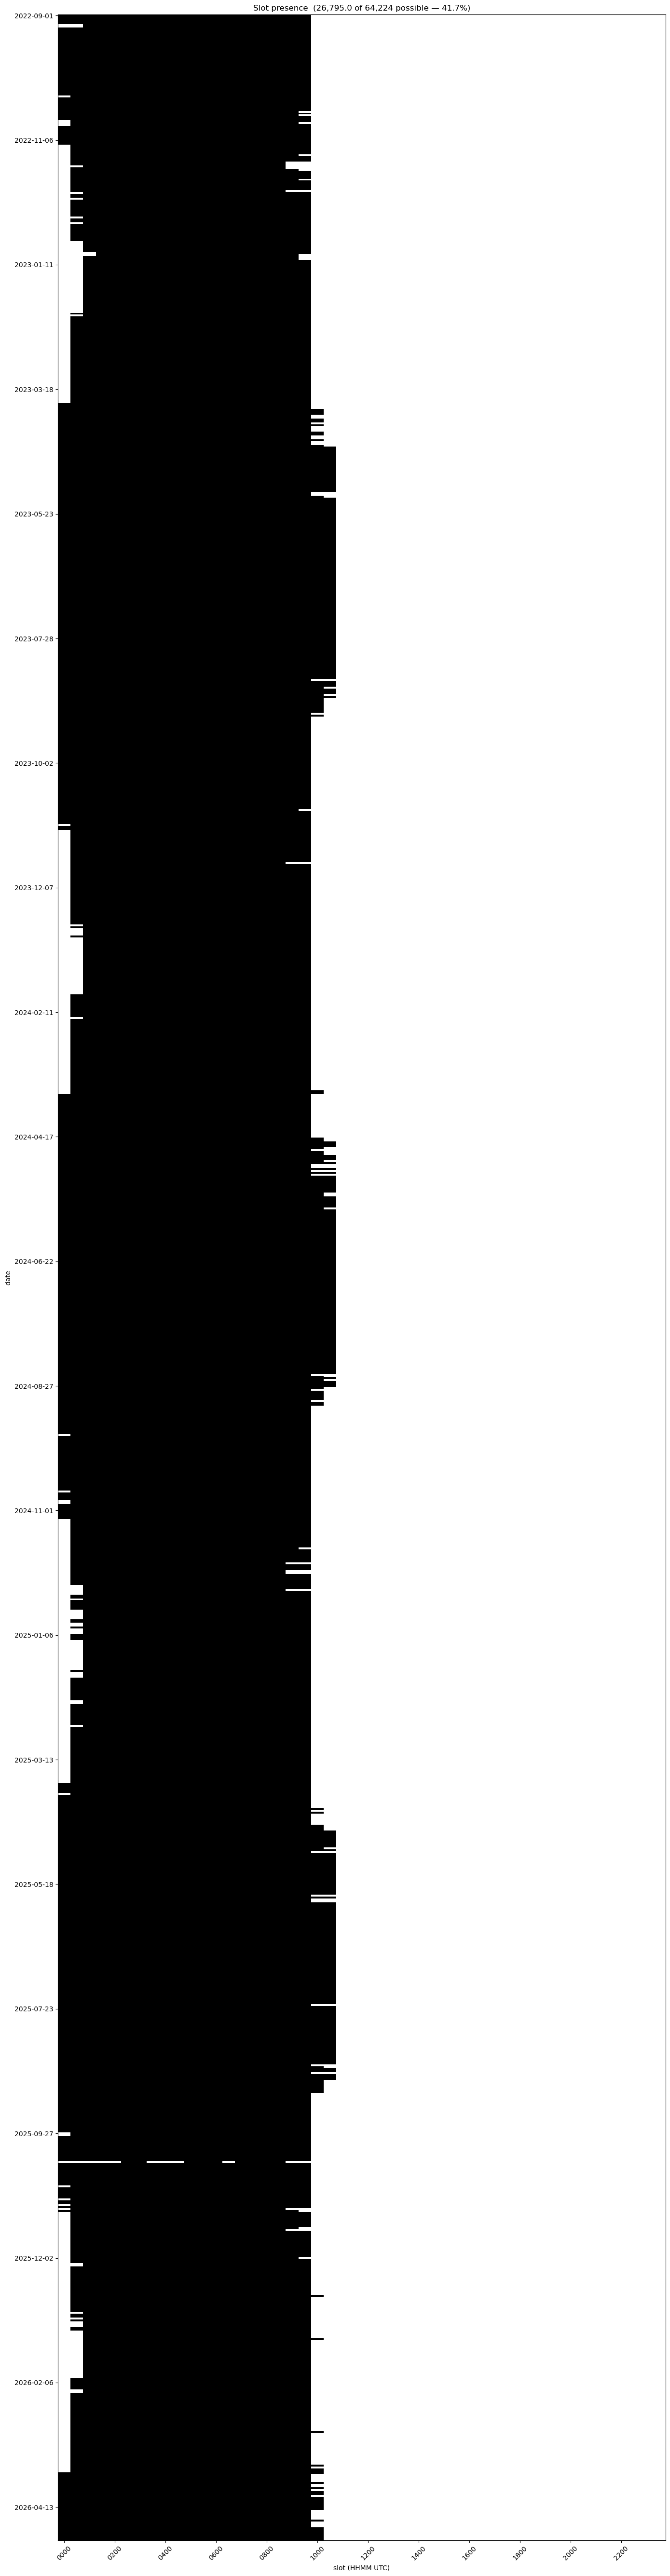

In [5]:
# Visualise daily slot coverage as a heatmap (rows=date, cols=slot)
if len(inv):
    pivot = (
        inv.assign(present=1)
           .pivot_table(index='date', columns='slot', values='present', fill_value=0)
    )
    full_slots = [f'{h:02d}{m:02d}' for h in range(24) for m in (0, 30)]
    pivot = pivot.reindex(columns=full_slots, fill_value=0)

    fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.04)))
    ax.imshow(pivot.values, aspect='auto', cmap='Greys', interpolation='nearest')
    ax.set_xlabel('slot (HHMM UTC)')
    ax.set_ylabel('date')
    ax.set_title(f'Slot presence  ({pivot.values.sum():,} of {pivot.size:,} possible — '
                 f'{100*pivot.values.sum()/pivot.size:.1f}%)')
    step = max(1, len(full_slots) // 12)
    ax.set_xticks(range(0, len(full_slots), step))
    ax.set_xticklabels(full_slots[::step], rotation=45)
    step_y = max(1, len(pivot) // 20)
    ax.set_yticks(range(0, len(pivot), step_y))
    ax.set_yticklabels([str(d) for d in pivot.index[::step_y]])
    plt.tight_layout()
    plt.show()

## 3. Per-file content sweep

Sample (or scan-all) the inventory to record, per file:

- valid pixel count for each data variable
- AOD min / max / mean
- max `n_sensors`, dominant confidence flag

Scanning all 25k files is slow; the default takes one slot per day.

In [6]:
# Sampling strategy: 'all'  | 'daily' (one slot/day) | int N (every Nth file)
SAMPLE = 'daily'

if SAMPLE == 'all':
    sample_df = inv
elif SAMPLE == 'daily':
    sample_df = inv.groupby('date', as_index=False).first()
elif isinstance(SAMPLE, int):
    sample_df = inv.iloc[::SAMPLE].copy()
else:
    raise ValueError(SAMPLE)

print(f'Scanning {len(sample_df):,} files (out of {len(inv):,}).')

Scanning 1,338 files (out of 26,795).


In [7]:
def summarise(path):
    """Return per-file diagnostics — robust to missing variables."""
    out = {'path': path}
    try:
        with xr.open_dataset(path) as ds:
            out['nlat'] = ds.sizes.get('lat')
            out['nlon'] = ds.sizes.get('lon')
            out['slot_utc'] = ds.attrs.get('slot_utc')
            out['vars'] = ';'.join(ds.data_vars)

            for v in ds.data_vars:
                arr = ds[v].values
                m = np.isfinite(arr)
                out[f'{v}__valid'] = int(m.sum())
                if v.startswith('AOD') and m.any():
                    sub = arr[m]
                    out[f'{v}__min']  = float(np.min(sub))
                    out[f'{v}__max']  = float(np.max(sub))
                    out[f'{v}__mean'] = float(np.mean(sub))
            if 'n_sensors' in ds.data_vars:
                ns = ds['n_sensors'].values
                if np.isfinite(ns).any():
                    out['n_sensors_max'] = float(np.nanmax(ns))
    except Exception as e:
        out['error'] = repr(e)
    return out

from concurrent.futures import ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=8) as ex:
    results = list(ex.map(summarise, sample_df['path'].tolist()))

scan = pd.DataFrame(results)
scan['timestamp'] = pd.to_datetime(scan['slot_utc'])
print(f'Scanned {len(scan):,} files;  errors: {scan.get("error").notna().sum() if "error" in scan else 0}')
scan.head()

Scanned 1,338 files;  errors: 0


,path,nlat,nlon,slot_utc,vars,AOD_merged__valid,AOD_merged__min,AOD_merged__max,AOD_merged__mean,AOD_std__valid,...,AOD_himawari__mean,n_sensors_max,AOD_modis_maiac__valid,AOD_modis_maiac__min,AOD_modis_maiac__max,AOD_modis_maiac__mean,AOD_std__min,AOD_std__max,AOD_std__mean,timestamp
0,/home/slow_data/Air_Quality/Stage_A/merged/202...,310,160,2022-09-01T00:00:00,AOD_merged;AOD_std;n_sensors;dominant_sensor;c...,318,0.000000,1.329934,0.066000,0,...,0.066000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-01
1,/home/slow_data/Air_Quality/Stage_A/merged/202...,310,160,2022-09-02T00:00:00,AOD_merged;AOD_std;n_sensors;dominant_sensor;c...,220,0.028221,1.262733,0.374823,0,...,0.374823,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-02
2,/home/slow_data/Air_Quality/Stage_A/merged/202...,310,160,2022-09-03T00:00:00,AOD_merged;AOD_std;n_sensors;dominant_sensor;c...,148,0.037664,1.667881,0.800549,0,...,0.800549,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-03
3,/home/slow_data/Air_Quality/Stage_A/merged/202...,310,160,2022-09-04T00:00:00,AOD_merged;AOD_std;n_sensors;dominant_sensor;c...,178,0.000000,1.429927,0.142388,0,...,0.142388,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-04
4,/home/slow_data/Air_Quality/Stage_A/merged/202...,310,160,2022-09-05T00:00:00,AOD_merged;AOD_std;n_sensors;dominant_sensor;c...,66,0.010943,1.929571,0.913485,0,...,0.913485,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-05


In [8]:
# Files that failed to open
if 'error' in scan.columns:
    bad = scan[scan['error'].notna()]
    print(f'Files with read errors: {len(bad)}')
    display(bad[['path', 'error']].head(20))

In [9]:
# Per-variable valid-pixel summary across scanned files
valid_cols = [c for c in scan.columns if c.endswith('__valid')]
if valid_cols:
    summary = pd.DataFrame({
        'mean_valid': scan[valid_cols].mean(),
        'min_valid' : scan[valid_cols].min(),
        'max_valid' : scan[valid_cols].max(),
        'pct_files_with_data': (scan[valid_cols] > 0).mean() * 100,
    })
    summary.index = [c.removesuffix('__valid') for c in summary.index]
    summary['mean_coverage_%'] = 100 * summary['mean_valid'] / (NLAT * NLON)
    summary = summary.sort_values('mean_valid', ascending=False)
    display(summary.round(2))

,mean_valid,min_valid,max_valid,pct_files_with_data,mean_coverage_%
ERA5_RH,49600.00,49600.0,49600.0,100.00,100.00
n_sensors,49600.00,49600.0,49600.0,100.00,100.00
ERA5_PBLH,49600.00,49600.0,49600.0,100.00,100.00
AOD_modis_maiac,3900.50,67.0,11802.0,0.60,7.86
AOD_phys_corrected,770.36,1.0,11802.0,100.00,1.55
AOD_merged,770.36,1.0,11802.0,100.00,1.55
dominant_sensor,770.36,1.0,11802.0,100.00,1.55
confidence_flag,770.36,1.0,11802.0,100.00,1.55
AOD_himawari,749.41,1.0,4596.0,99.93,1.51
AOD_std,1.81,0.0,1342.0,0.45,0.00


In [10]:
# AOD value distribution across scanned files
for v in ['AOD_merged', 'AOD_phys_corrected']:
    cols = [f'{v}__min', f'{v}__max', f'{v}__mean']
    if all(c in scan.columns for c in cols):
        print(f'\n--- {v} ---')
        display(scan[cols].describe().round(3))


--- AOD_merged ---


,AOD_merged__min,AOD_merged__max,AOD_merged__mean
count,1338.000,1338.000,1338.000
mean,0.056,1.427,0.352
std,0.179,0.732,0.294
min,0.000,0.000,0.000
25%,0.000,1.002,0.149
50%,0.000,1.528,0.287
75%,0.028,1.921,0.469
max,1.999,4.549,1.999



--- AOD_phys_corrected ---


,AOD_phys_corrected__min,AOD_phys_corrected__max,AOD_phys_corrected__mean
count,1338.000,1338.000,1338.000
mean,0.000,0.004,0.001
std,0.000,0.003,0.001
min,0.000,0.000,0.000
25%,0.000,0.001,0.000
50%,0.000,0.003,0.000
75%,0.000,0.005,0.001
max,0.007,0.019,0.007


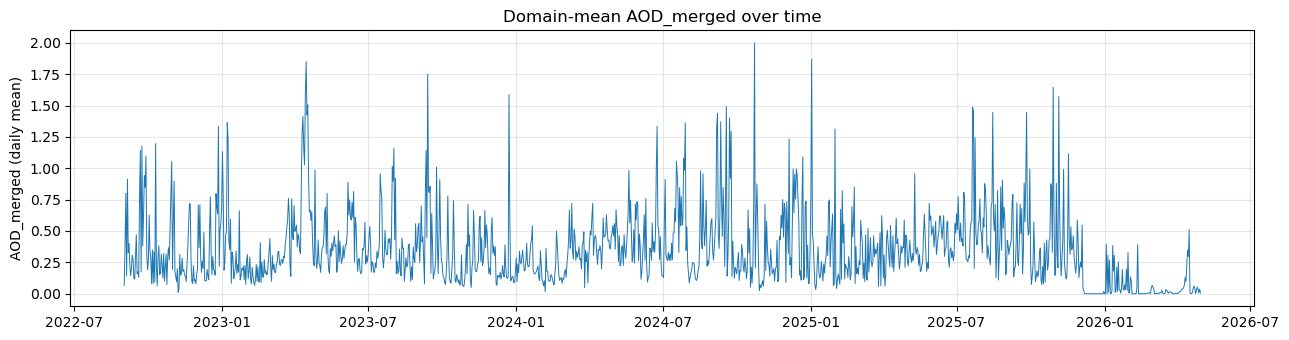

In [11]:
# Time series: daily mean AOD_merged across scanned files
if 'AOD_merged__mean' in scan.columns:
    ts = scan.set_index('timestamp')['AOD_merged__mean'].dropna()
    if len(ts):
        daily_ts = ts.resample('D').mean()
        fig, ax = plt.subplots(figsize=(13, 3.5))
        ax.plot(daily_ts.index, daily_ts.values, lw=0.7)
        ax.set_ylabel('AOD_merged (daily mean)')
        ax.set_title('Domain-mean AOD_merged over time')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## 4. Sample slot — quick map

In [12]:
if 'AOD_merged__mean' in scan.columns:
    sample_path = (
        scan.sort_values('AOD_merged__valid', ascending=False)
            .iloc[0]['path']
    )
else:
    sample_path = inv.iloc[len(inv) // 2]['path']

print('Plotting:', sample_path)
ds = xr.open_dataset(sample_path)
ds

Plotting: /home/slow_data/Air_Quality/Stage_A/merged/2025/10/12/merged_20251012_0230.nc


<xarray.Dataset> Size: 2MB
Dimensions:             (lat: 310, lon: 160)
Coordinates:
  * lat                 (lat) float32 1kB 23.48 23.42 23.38 ... 8.075 8.025
  * lon                 (lon) float32 640B 102.0 102.1 102.1 ... 109.9 110.0
Data variables:
    AOD_merged          (lat, lon) float32 198kB ...
    AOD_std             (lat, lon) float32 198kB ...
    n_sensors           (lat, lon) float32 198kB ...
    dominant_sensor     (lat, lon) float32 198kB ...
    confidence_flag     (lat, lon) float32 198kB ...
    AOD_phys_corrected  (lat, lon) float32 198kB ...
    ERA5_RH             (lat, lon) float32 198kB ...
    ERA5_PBLH           (lat, lon) float32 198kB ...
    AOD_modis_maiac     (lat, lon) float32 198kB ...
Attributes:
    title:        Vietnam merged AOD — Stage A 30-min product
    institution:  Hanoi University of Science and Technology
    slot_utc:     2025-10-12T02:30:00
    Conventions:  CF-1.8

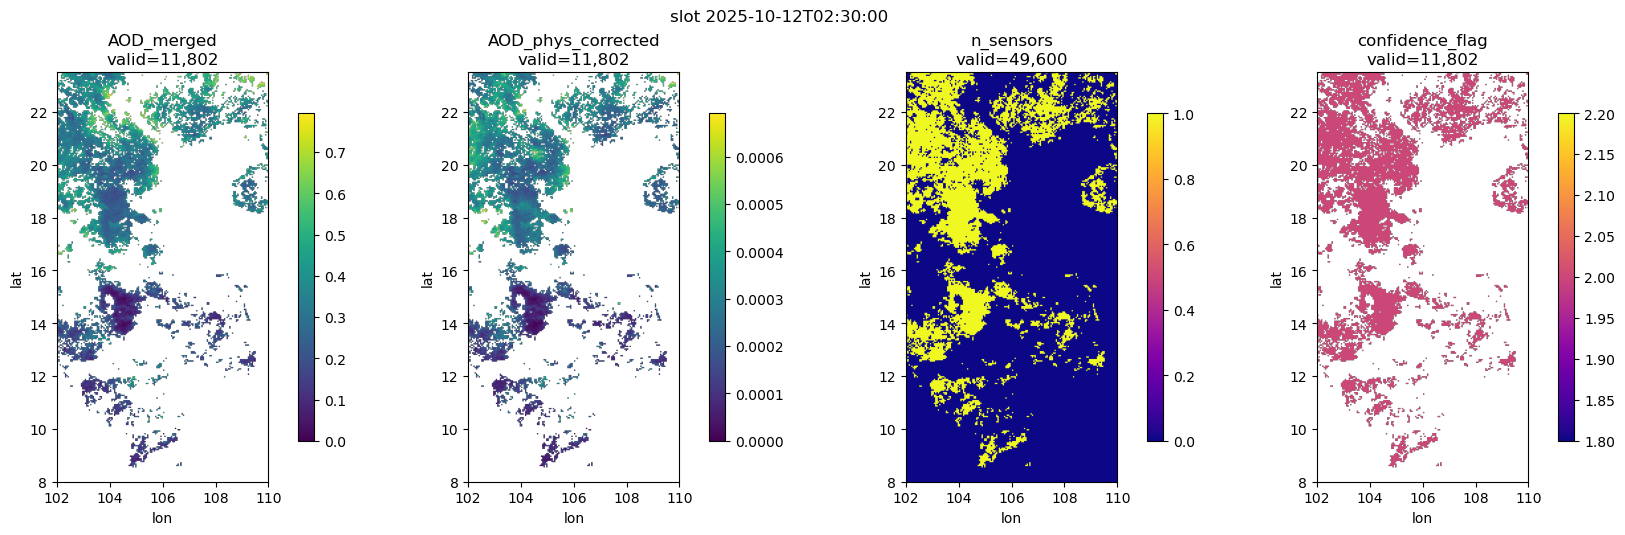

In [13]:
plot_vars = [v for v in ['AOD_merged', 'AOD_phys_corrected', 'n_sensors', 'confidence_flag']
             if v in ds.data_vars]

fig, axes = plt.subplots(1, len(plot_vars), figsize=(4.2 * len(plot_vars), 5),
                         constrained_layout=True)
if len(plot_vars) == 1:
    axes = [axes]
extent = (LONS[0] - 0.025, LONS[-1] + 0.025, LATS[-1] - 0.025, LATS[0] + 0.025)
for ax, v in zip(axes, plot_vars):
    arr = ds[v].values
    im = ax.imshow(arr, extent=extent, origin='upper',
                   cmap='viridis' if v.startswith('AOD') else 'plasma')
    ax.set_title(f'{v}\nvalid={np.isfinite(arr).sum():,}')
    ax.set_xlabel('lon'); ax.set_ylabel('lat')
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle(f"slot {ds.attrs.get('slot_utc')}", y=1.04)
plt.show()
ds.close()

## 5. Per-year / month rollup

In [14]:
if len(inv):
    by_ym = (
        inv.assign(ym=inv['timestamp'].dt.to_period('M'))
           .groupby('ym')
           .agg(files=('path', 'size'),
                days=('date', 'nunique'),
                size_mb=('size_kb', lambda s: s.sum() / 1024))
           .reset_index()
    )
    by_ym['avg_slots_per_day'] = (by_ym['files'] / by_ym['days']).round(1)
    display(by_ym)

,ym,files,days,size_mb,avg_slots_per_day
0,2022-09,596,30,173.197820,19.9
1,2022-10,613,31,192.637960,19.8
2,2022-11,566,30,188.750801,18.9
3,2022-12,581,31,193.239046,18.7
4,2023-01,553,31,189.273816,17.8
5,2023-02,526,28,184.236805,18.8
6,2023-03,598,31,218.291428,19.3
7,2023-04,633,30,219.840485,21.1
8,2023-05,677,31,227.893577,21.8
9,2023-06,660,30,206.609305,22.0
